In [64]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.saving import load_model
from tensorflow.keras.utils import plot_model
import keras
import keras_nlp
from helper import init_resource_dicts, get_arrays, get_strings

feat_file = "./Feature_files/featsNew"
symbol2feats, suffix2label, label2suffix = init_resource_dicts(feat_file)

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

In [65]:
URs, SRs, Ls = get_strings("EqualDefault/equalFreq_train.txt")
X, Y = get_arrays(URs, SRs, Ls, symbol2feats, suffix2label, override_max_syll=5)
Y = tf.keras.utils.to_categorical(Y, num_classes = 3)

print(X[0].shape) # (5,19)
print(Y[0].shape) # (3,)

dummy_input = tf.expand_dims(X[0], axis=0)  # Add batch dimension

(5, 19)
(3,)


In [66]:
"""Model definition"""

def get_encoder_model(d_model=32, num_heads=1, dff=64, dropout_rate=0.1):
    # Input shape: 5 time steps, 19 features
    encoder_inputs = keras.Input(shape=(5, 19)) 
    
    # Adding position embeddings
    position_embeddings = keras_nlp.layers.PositionEmbedding(sequence_length=5)(encoder_inputs)
    encoder_outputs = encoder_inputs + position_embeddings

    # Projecting input to d_model dimensions
    encoder_outputs = keras.layers.Dense(d_model)(encoder_outputs)
    
    # Single encoder layer
    attention = keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
    attention_output = attention(encoder_outputs, encoder_outputs)
    attention_output = keras.layers.Dropout(dropout_rate)(attention_output)
    attention_output = keras.layers.LayerNormalization(epsilon=1e-6)(encoder_outputs + attention_output)
    
    # Feed-forward network
    outputs = keras.layers.Dense(dff, activation="relu")(attention_output)
    outputs = keras.layers.Dense(d_model)(outputs)
    outputs = keras.layers.Dropout(dropout_rate)(outputs)
    encoder_outputs = keras.layers.LayerNormalization(epsilon=1e-6)(attention_output + outputs)
    
    # Classification head
    outputs = keras.layers.Flatten()(encoder_outputs)
    outputs = keras.layers.Dense(3, activation="softmax")(outputs) 
    
    return keras.Model(inputs=encoder_inputs, outputs=outputs)

In [67]:
load_filepath = f"./Models/TransformerEncoder_Results_batch32_latent16/equalFreq_model_0.keras"
model = load_model(load_filepath)

for layer in model.layers:
    print(f"Layer Name: {layer.name}, Layer Type: {type(layer)}")
    
plot_model(model, to_file="model_structure.png", show_shapes=True, show_layer_names=True)

model.summary()

Layer Name: input_layer_19, Layer Type: <class 'keras.src.layers.core.input_layer.InputLayer'>
Layer Name: position_embedding_19, Layer Type: <class 'keras_nlp.src.layers.modeling.position_embedding.PositionEmbedding'>
Layer Name: dense_70, Layer Type: <class 'keras.src.layers.core.dense.Dense'>
Layer Name: multi_head_attention_19, Layer Type: <class 'keras.src.layers.attention.multi_head_attention.MultiHeadAttention'>
Layer Name: dropout_52, Layer Type: <class 'keras.src.layers.regularization.dropout.Dropout'>
Layer Name: layer_normalization_34, Layer Type: <class 'keras.src.layers.normalization.layer_normalization.LayerNormalization'>
Layer Name: dense_71, Layer Type: <class 'keras.src.layers.core.dense.Dense'>
Layer Name: dense_72, Layer Type: <class 'keras.src.layers.core.dense.Dense'>
Layer Name: dropout_53, Layer Type: <class 'keras.src.layers.regularization.dropout.Dropout'>
Layer Name: layer_normalization_35, Layer Type: <class 'keras.src.layers.normalization.layer_normalizatio

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 5, 19)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding… │ (None, 5, 19)     │         95 │ input_layer_19[0… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_53 (Add)        │ (None, 5, 19)     │          0 │ input_layer_19[0… │
│                     │                   │            │ position_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_70 (Dense)    │ (None, 5, 32)     │        640 │ add_53[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 5, 32)     │      4,224 │ dense_70[0][0],   │
│ (MultiHeadAttentio… │                   │            │ dense_70[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_52          │ (None, 5, 32)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_54 (Add)        │ (None, 5, 32)     │          0 │ dense_70[0][0],   │
│                     │                   │            │ dropout_52[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 5, 32)     │         64 │ add_54[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_71 (Dense)    │ (None, 5, 64)     │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_72 (Dense)    │ (None, 5, 32)     │      2,080 │ dense_71[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_53          │ (None, 5, 32)     │          0 │ dense_72[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_55 (Add)        │ (None, 5, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_53[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 5, 32)     │         64 │ add_55[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_17          │ (None, 160)       │          0 │ layer_normalizat… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_73 (Dense)    │ (None, 3)         │        483 │ flatten_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,288 (114.41 KB)

 Trainable params: 9,762 (38.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,526 (76.28 KB)

UW0 B IH1 CH
W AH0
4
(1, 3)
Predictions: [[0.5761154  0.21194227 0.21194227]]


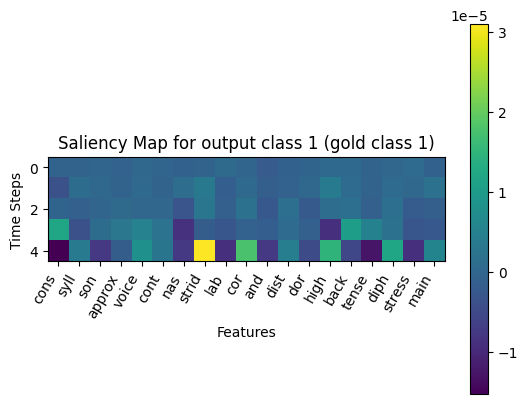

(1, 3)
Predictions: [[0.5761154  0.21194227 0.21194227]]


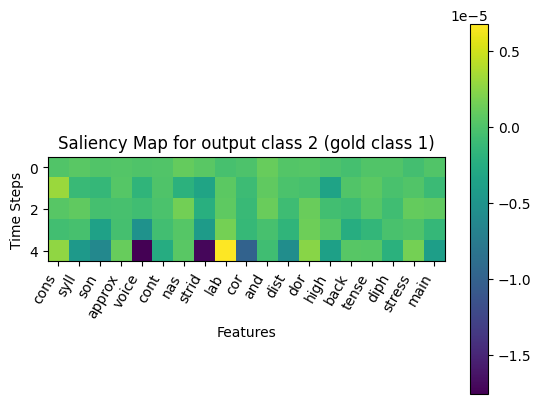

(1, 3)
Predictions: [[0.5761154  0.21194227 0.21194227]]


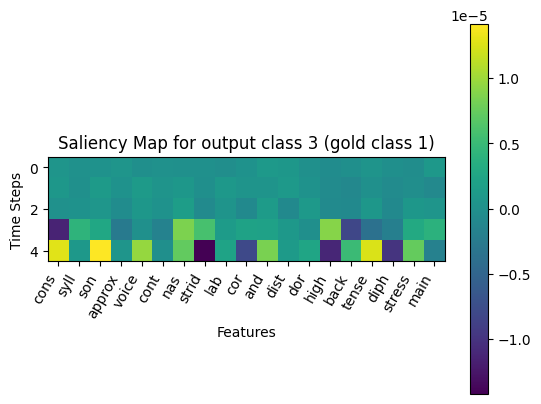

In [68]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

feature_names = ["cons", "syll", "son", "approx", "voice", "cont", "nas", "strid", "lab", "cor", "and", 
				 "dist", "dor", "high", "back", "tense", "diph", "stress", "main"]

# # Dummy input for gradient calculation
# dummy_input = np.random.random((1, 5, 19)).astype(np.float32)  # Batch size = 1, Sequence length = 5, Features = 19
URs, SRs, Ls = get_strings("EqualDefault/equalFreq_train.txt")
X, Y = get_arrays(URs, SRs, Ls, symbol2feats, suffix2label, override_max_syll=5)
Y = tf.keras.utils.to_categorical(Y, num_classes = 3)

print(URs[0])
print(SRs[0])
print(Ls[0])

dummy_input = tf.expand_dims(X[0], axis=0)  # Add batch dimension
dummy_input = tf.convert_to_tensor(dummy_input) 
# print(dummy_input.shape) # (1, 5, 19)

# Create a model
model = load_model(load_filepath)

for i in range(3):
	# Compute gradients with tf.GradientTape
	with tf.GradientTape() as tape:
		tape.watch(dummy_input)  # Watch the input for gradient computation
		predictions = model(dummy_input)  # Forward pass
		print(predictions.shape)
		print(f"Predictions: {softmax(predictions)}")
		output = predictions[:, i]  # Choose the first class for gradients

	# Compute gradients of the output w.r.t. the input
	grads = tape.gradient(output, dummy_input)

	# Visualize the gradients
	plt.imshow(grads[0], cmap="viridis")
	plt.title(f"Saliency Map for output class {i+1} (gold class 1)")
	plt.xlabel("Features")
	plt.ylabel("Time Steps")
	plt.xticks(ticks=np.arange(len(feature_names)), labels=feature_names, rotation=60, ha="right")
	plt.colorbar()
	plt.show()

L AH0 D AH1 F
L EY0
5
(1, 3)
Predictions: [[0.21194167 0.57611626 0.21194203]]


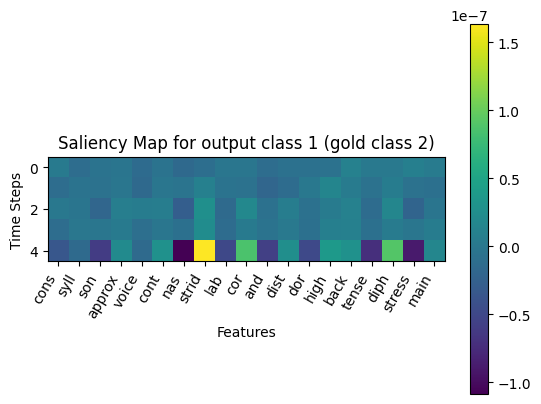

(1, 3)
Predictions: [[0.21194167 0.57611626 0.21194203]]


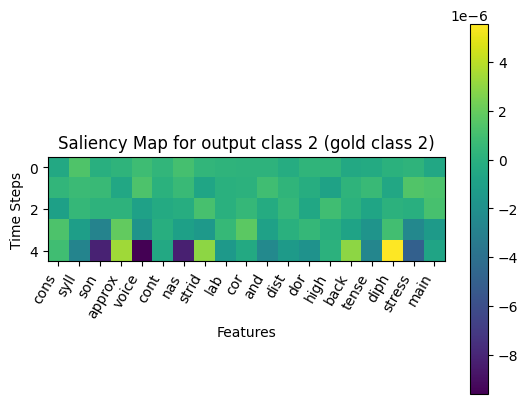

(1, 3)
Predictions: [[0.21194167 0.57611626 0.21194203]]


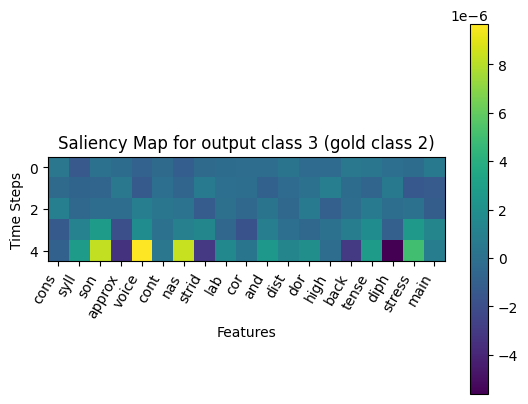

In [69]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# # Dummy input for gradient calculation
# dummy_input = np.random.random((1, 5, 19)).astype(np.float32)  # Batch size = 1, Sequence length = 5, Features = 19
URs, SRs, Ls = get_strings("EqualDefault/equalFreq_train.txt")
X, Y = get_arrays(URs, SRs, Ls, symbol2feats, suffix2label, override_max_syll=5)
Y = tf.keras.utils.to_categorical(Y, num_classes = 3)

print(URs[1])
print(SRs[1])
print(Ls[1])

dummy_input = tf.expand_dims(X[1], axis=0)  # Add batch dimension
dummy_input = tf.convert_to_tensor(dummy_input) 
# print(dummy_input.shape) # (1, 5, 19)

# Create a model
model = load_model(load_filepath)

for i in range(3):
	# Compute gradients with tf.GradientTape
	with tf.GradientTape() as tape:
		tape.watch(dummy_input)  # Watch the input for gradient computation
		predictions = model(dummy_input)  # Forward pass
		print(predictions.shape)
		print(f"Predictions: {softmax(predictions)}")
		output = predictions[:, i]  # Choose the first class for gradients

	# Compute gradients of the output w.r.t. the input
	grads = tape.gradient(output, dummy_input)

	# Visualize the gradients
	plt.imshow(grads[0], cmap="viridis")
	plt.title(f"Saliency Map for output class {i+1} (gold class 2)")
	plt.xlabel("Features")
	plt.ylabel("Time Steps")
	plt.xticks(ticks=np.arange(len(feature_names)), labels=feature_names, rotation=60, ha="right")
	plt.colorbar()
	plt.show()

F EH0 N OW1 N
Y IY0
5
(1, 3)
Predictions: [[0.21194158 0.21194157 0.57611686]]


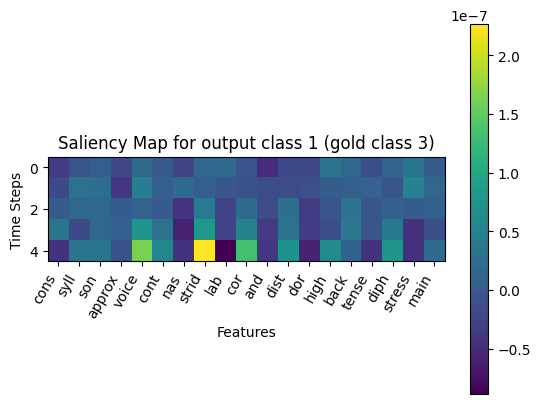

(1, 3)
Predictions: [[0.21194158 0.21194157 0.57611686]]


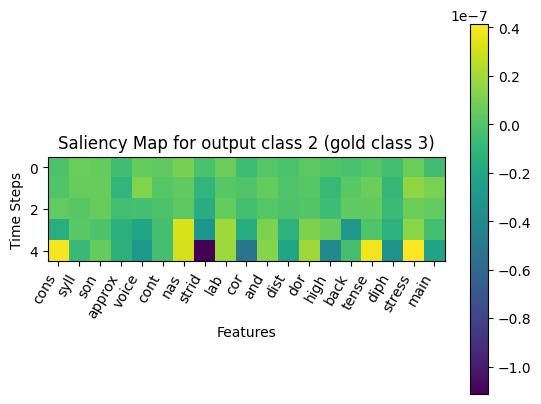

(1, 3)
Predictions: [[0.21194158 0.21194157 0.57611686]]


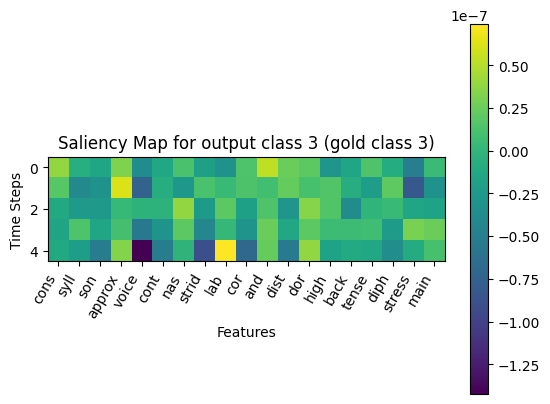

In [70]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# # Dummy input for gradient calculation
# dummy_input = np.random.random((1, 5, 19)).astype(np.float32)  # Batch size = 1, Sequence length = 5, Features = 19
URs, SRs, Ls = get_strings("EqualDefault/equalFreq_train.txt")
X, Y = get_arrays(URs, SRs, Ls, symbol2feats, suffix2label, override_max_syll=5)
Y = tf.keras.utils.to_categorical(Y, num_classes = 3)

print(URs[7])
print(SRs[7])
print(Ls[7])

dummy_input = tf.expand_dims(X[7], axis=0)  # Add batch dimension
dummy_input = tf.convert_to_tensor(dummy_input) 
# print(dummy_input.shape) # (1, 5, 19)

# Create a model
model = load_model(load_filepath)

for i in range(3):
	# Compute gradients with tf.GradientTape
	with tf.GradientTape() as tape:
		tape.watch(dummy_input)  # Watch the input for gradient computation
		predictions = model(dummy_input)  # Forward pass
		print(predictions.shape)
		print(f"Predictions: {softmax(predictions)}")
		output = predictions[:, i]  # Choose the first class for gradients

	# Compute gradients of the output w.r.t. the input
	grads = tape.gradient(output, dummy_input)

	# Visualize the gradients
	plt.imshow(grads[0], cmap="viridis")
	plt.title(f"Saliency Map for output class {i+1} (gold class 3)")
	plt.xlabel("Features")
	plt.ylabel("Time Steps")
	plt.xticks(ticks=np.arange(len(feature_names)), labels=feature_names, rotation=60, ha="right")
	plt.colorbar()
	plt.show()